In [ ]:
import pandas as pd
from constantes import pasta_data_04_load_inscritos,pasta_data_05_processed_analise_012_1,pasta_data_05_processed_analise_012_1_X_treino,pasta_data_05_processed_analise_012_1_y_treino
from sklearn.linear_model import LogisticRegression

# Configuração de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 1. CARREGAR OS DADOS
df_base = pd.read_parquet(str(pasta_data_04_load_inscritos))

filtro_treino_base = (df_base['subarea_conhecimento'] == 'MEDICINA')

df_base=df_base[filtro_treino_base].copy()

# 2. CRIAR VARIÁVEIS NOVAS (Vetorizado, muito mais rápido)
df_base['gap'] = df_base['media_enem'] - df_base['nota_corte_gp']

def idade(X:str):
    lista = X.split('/')
    ano= lista[2]
    return 2026 - int(ano)

df_base['idade'] = df_base['data_nascimento'].apply(idade)




# 3. DUMIZAR VARIÁVEIS CATEGÓRICAS
# Isso cria as colunas 0 e 1 e JÁ EXCLUI a 'nome_cine_area_geral' original
df = pd.get_dummies(df_base, columns=['beneficiado_creduc_fies','modalidade_fies','regiao_morar','natureza_juridica_mantenedora','etnia_cor','turno','ensino_medio_escola_publica','conceito_curso_gp','concluiu_curso_superior','opcao_curso'], drop_first=True)

# 4. FILTRAR A BASE DE DADOS
contratados = ['CONTRATADA']
nao_contratados = ['NÃO CONTRATADO']

filtro = df['situacao_fies'].isin(contratados + nao_contratados)
df = df[filtro].copy()

# 5. CRIAR A VARIÁVEL ALVO (Y) BINÁRIA
df['contratado'] = df['situacao_fies'].apply(lambda x: 1 if x in contratados else 0)


# 6. PESCAR AS COLUNAS DUMMIES
# O Python procura e guarda apenas as colunas que começam com esse nome
colunas_dummies_turno = [col for col in df.columns if col.startswith('turno_')]

colunas_dummies_ensino_medio_escola_publica = [col for col in df.columns if col.startswith('ensino_medio_escola_publica_')]
colunas_dummies_etnia = [col for col in df.columns if col.startswith('etnia_cor_')]
colunas_dummies_regiao = [col for col in df.columns if col.startswith('regiao_morar_')]
colunas_dummies_natureza = [col for col in df.columns if col.startswith('natureza_juridica_mantenedora_')]
colunas_dummies_opcao_curso = [col for col in df.columns if col.startswith('opcao_curso')]
colunas_dummies_conceito_curso = [col for col in df.columns if col.startswith('conceito_curso_gp')]
colunas_dummies_conceito_concluiu_curso_superior = [col for col in df.columns if col.startswith('concluiu_curso_superior')]
colunas_dummies_conceito_concluiu_modfies = [col for col in df.columns if col.startswith('modalidade_fies')]
colunas_dummies_conceito_concluiu_BENEFcreduc = [col for col in df.columns if col.startswith('beneficiado_creduc_fies')]






# 9. CRIAR A LISTA EXATA DE FEATURES
# Juntamos as variáveis que você escolheu com as dummies
df['renda_gap']=df['renda_per_capita'] * df['gap']


features_exatas = ['renda_per_capita', 'gap','idade','nota_corte_gp','renda_gap']+ colunas_dummies_conceito_concluiu_BENEFcreduc + colunas_dummies_conceito_concluiu_modfies + colunas_dummies_opcao_curso + colunas_dummies_conceito_concluiu_curso_superior + colunas_dummies_conceito_curso + colunas_dummies_regiao + colunas_dummies_natureza + colunas_dummies_etnia + colunas_dummies_turno + colunas_dummies_ensino_medio_escola_publica



# Faz o Raio-X apenas nas colunas que vão pro modelo
print("--- Quantidade de NaNs por coluna ---")
print(df[features_exatas].isna().sum())

# Isso garante que se o aluno sumir, ele some das duas listas
df_limpo = df.dropna(subset=features_exatas).copy()



df_treino = df_limpo
df_teste = df_limpo


# 8. SEPARAR O X E O Y
# O X recebe ESTRITAMENTE as colunas da sua lista branca
X = df_treino[features_exatas]

# O Y recebe a sua resposta
Y = df_treino['contratado']



X_teste = df_teste[features_exatas]

# O Y recebe a sua resposta
Y_teste= df_teste['contratado']


print('coluna x linha do X com NaN inclusos:',X.shape)

print('coluna x linha do X sem NaN inclusos:',X.shape)



# 12. SALVAR MATRIZES PROCESSADAS (ABT)
import os

# Definindo o diretório de destino
caminho_salvar = str(pasta_data_05_processed_analise_012_1)

# Criando os caminhos completos
path_x_treino = os.path.join(caminho_salvar, 'x_treino.parquet')
path_y_treino = os.path.join(caminho_salvar, 'y_treino.parquet')
path_x_teste = os.path.join(caminho_salvar, 'x_teste.parquet')
path_y_teste = os.path.join(caminho_salvar, 'y_teste.parquet')

# Salvando os arquivos em formato Parquet para manter a performance
X.to_parquet(path_x_treino,index=False)
Y.to_frame().to_parquet(path_y_treino,index=False)
X_teste.to_parquet(path_x_teste,index=False)
Y_teste.to_frame().to_parquet(path_y_teste,index=False)

print('-'*60)
print(f"Arquivos da ABT salvos com sucesso em:\n{caminho_salvar}")
print(f"Registros de Treino: {len(X):,}")
print(f"Registros de Teste: {len(X_teste):,}")

--- Quantidade de NaNs por coluna ---
renda_per_capita                                                                                                            0
gap                                                                                                                         1
idade                                                                                                                       0
nota_corte_gp                                                                                                               0
renda_gap                                                                                                                   1
beneficiado_creduc_fies_NÃO                                                                                                 0
beneficiado_creduc_fies_SIM                                                                                                 0
modalidade_fies_Modalidade II                                                   

/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


corte, 0.5149933550310963
Acurácia da Árvore (Depth 12): 0.6625

=== Relatório de Classificação ===
              precision    recall  f1-score   support

           0       0.85      0.63      0.72     16430
           1       0.47      0.75      0.58      7315

    accuracy                           0.66     23745
   macro avg       0.66      0.69      0.65     23745
weighted avg       0.73      0.66      0.68     23745



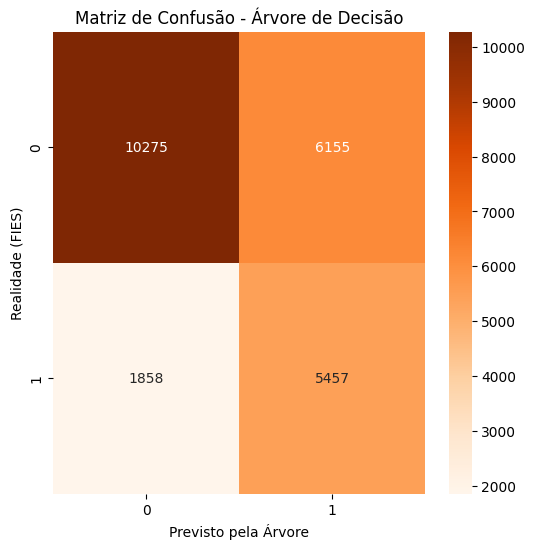

roc:  0.7466313934007818


,Variavel,Importancia
0,opcao_curso_2,0.296482
1,opcao_curso_3,0.165755
2,nota_corte_gp,0.114352
3,gap,0.090154
4,renda_gap,0.088766
5,renda_per_capita,0.053751
6,ensino_medio_escola_publica_SIM,0.044512
7,natureza_juridica_mantenedora_PRIVADA COM FINS...,0.025265
8,conceito_curso_gp_4,0.021338
9,conceito_curso_gp_5,0.020085


,Variavel,Importancia
0,opcao_curso_2,0.296482
1,opcao_curso_3,0.165755
2,nota_corte_gp,0.114352
3,gap,0.090154
4,renda_gap,0.088766
5,renda_per_capita,0.053751
6,ensino_medio_escola_publica_SIM,0.044512
7,natureza_juridica_mantenedora_PRIVADA COM FINS...,0.025265
8,conceito_curso_gp_4,0.021338
9,conceito_curso_gp_5,0.020085


In [ ]:
# analsie 12 mas apenas pra cursos de medicina ( inclui a base toda de 2019 a 2021)
from sklearn.ensemble import RandomForestClassifier
import pandas as pd


df_base_x= pd.read_parquet(str(pasta_data_05_processed_analise_012_1_X_treino))

df_base_y= pd.read_parquet(str(pasta_data_05_processed_analise_012_1_y_treino))



X_treino = df_base_x

Y_treino = df_base_y


max_depth= 42



modelo = RandomForestClassifier(max_depth=max_depth,
                                n_estimators=1000,
                                n_jobs=-1,
                                class_weight='balanced',
                                random_state=42,
                                min_samples_leaf=125,)      # Garante que cada "folha" tenha pelo menos 50 alunos (evita regras ruidosas)

modelo.fit(X_treino,Y_treino)



if max_depth < 3:

    from sklearn.tree import plot_tree
    import matplotlib.pyplot as plt

    # 1. Configurar o tamanho da "tela" (fundamental para a árvore caber)
    plt.figure(figsize=(40, 20)) 

    # 2. Desenhar a árvore
    plot_tree(
        modelo,
        feature_names=X_treino.columns,                 # Troca "X[0]" pelo nome real (ex: renda_per_capita)
        class_names=['Não Contratado', 'Contratado'],   # Traduz o 0 e 1 no gráfico final
        filled=True,                                    # Colore os nós (ex: azul pra contratado, laranja pra não)
        rounded=True,                                   # Deixa as caixinhas arredondadas (estética)
    fontsize=8                                          # Tamanho da letra
    )

    # 3. Mostrar o gráfico
    plt.show()

visualizar_arvore= 'nao'

if visualizar_arvore == 'sim':

    from sklearn.tree import export_text

    # Transforma a árvore em regras de texto
    regras_arvore = export_text(
        modelo, 
        feature_names=list(X_treino.columns), # Garante que os nomes reais apareçam
         max_depth=max_depth                  # Mostra até a profundidade que você quiser
    )

    print(regras_arvore)

# primeiro tentar com a base original so pra espiar como esta os if e else e depois fazer teste...



#----------------------------------

X_teste = df_base_x

y_teste =df_base_y

#y_predict= modelo.predict(X_teste)

# a. Em vez de prever a classe direto, pegamos a probabilidade
y_probs = modelo.predict_proba(X_teste)[:, 1]



from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_auc_score,roc_curve
import seaborn as sns
import matplotlib.pyplot as plt



fpr, tpr, thresholds = roc_curve(y_teste, y_probs)
melhor_indice = (tpr - fpr).argmax()
threshold = thresholds[melhor_indice]
corte= threshold
print('corte,',corte)

# b. Aplicamos o threshold (você pode testar 0.5, 0.6, etc, como fez na Regressão)
y_predict = (y_probs >= threshold).astype(int)
# 1. Avaliação Geral
acuracia = accuracy_score(y_teste, y_predict)
print(f"Acurácia da Árvore (Depth 12): {acuracia:.4f}\n")

# 2. Relatório Detalhado (Onde a mágica do Recall acontece)
print("=== Relatório de Classificação ===")
print(classification_report(y_teste, y_predict))

# 3. Matriz de Confusão Visual
matriz = confusion_matrix(y_teste, y_predict)

plt.figure(figsize=(6, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Oranges') 
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.xlabel("Previsto pela Árvore")
plt.ylabel("Realidade (FIES)")
plt.show()

roc = roc_auc_score(y_teste,y_probs)

print('roc: ', roc)



import pandas as pd

from constantes import pasta_data_04_load_inscritos

df=pd.read_parquet(pasta_data_04_load_inscritos)

df2= df.groupby(['situacao_fies','percentual_financiamento'],as_index=False).size().sort_values('size',ascending=False)

df2.groupby(['situacao_fies'],as_index=False).size().sort_values('size',ascending=False)


# import joblib
# from constantes import pasta_modelo_analise_017
# joblib.dump(modelo, str(pasta_modelo_analise_017))
# print(f'Modelo salvo em: {str(pasta_modelo_analise_017)}')

# MODELO PESA MUITO ENTAO NEM ADIANTA SALVAR PARA O GIT HUB


import pandas as pd

# 1. Cria um DataFrame juntando o nome da coluna e a importância calculada
df_importancias = pd.DataFrame({
    'Variavel': X_treino.columns,
    'Importancia': modelo.feature_importances_
})

# 2. Ordena da mais importante (maior valor) para a menos importante
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# 3. Reseta o índice para ficar mais bonito e imprime
df_importancias = df_importancias.reset_index(drop=True)

filtro = ~(df_importancias['Importancia'] == 0)

display(df_importancias[filtro])#type: ignore

display(df_importancias)#type: ignore